# TV-penalty ablation of Joint MAP, with exact min-cut certificates

## Setup — load the persisted runs

In [1]:
from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))

from sampler_research.io import load_sampler_arrays
from sampler_research import method4_mrf as rm4
from sampler_research.graph import grid_edges_8

DATASET = "phase_1_homoscedastic"
DATA_DIR = PROJECT_ROOT / "outputs" / "data"
RUNS_DIR = PROJECT_ROOT / "outputs" / "runs"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDGES = grid_edges_8(8, 8)

# Toy GMM parameters (the decoder emits only pi, mu, sigma, coords).
d = load_sampler_arrays(DATA_DIR / f"{DATASET}.npz")
pi, mu, sigma = d["pi"], d["mu"], d["sigma"]


def read_scores(path):
    """Read a persisted *_scores.csv into list-of-dict rows (float where possible)."""
    rows = []
    with open(path, newline="") as fh:
        for raw in csv.DictReader(fh):
            row = {}
            for k, v in raw.items():
                try:
                    row[k] = float(v)
                except (TypeError, ValueError):
                    row[k] = v
            rows.append(row)
    return rows


# Arrays from .npz; metric tables from .csv.
A = np.load(RUNS_DIR / "stage_a_baselines" / f"{DATASET}_baselines.npz")
B = np.load(RUNS_DIR / "stage_b_regularised_map" / f"{DATASET}_regularised_map.npz")
C = np.load(RUNS_DIR / "stage_c_method4_mrf" / f"{DATASET}_method4_mrf.npz")
T = np.load(RUNS_DIR / "stage_b_tv_ablation" / f"{DATASET}_tv_ablation.npz")

scores_a = {r["baseline"]: r for r in read_scores(RUNS_DIR / "stage_a_baselines" / "stage_a_scores.csv")}
scores_t = read_scores(RUNS_DIR / "stage_b_tv_ablation" / "stage_b_tv_scores.csv")
rows_adam = [r for r in scores_t if r["arm"] == "adam-tv"]
rows_cut = [r for r in scores_t if r["arm"] == "cut-tv"]
rows_quad = [r for r in scores_t if r["arm"] == "cut-quad"]

# Mode-selection MRF's extracted modes are the shared reference for the smearing diagnostic.
MODE_VALUES, VALID_MASK = C["mode_values"], C["valid_mask"]

ANCHORS = ["iid", "mode_map", "smoothed_map", "a_star"]

print(f"dataset: {DATASET}   grid: {pi.shape[0]}x{pi.shape[1]}   K={pi.shape[-1]} components")
print(f"loaded   TV (Adam): {len(rows_adam)} λ   TV (exact): {len(rows_cut)} λ   exact quad cut: {len(rows_quad)} λ")
print(f"value grids: G={int(T['n_levels'])} (TV) / G={int(T['n_levels_quad'])} (quad)   "
      f"spacing h={float(T['value_grid_tv'][1] - T['value_grid_tv'][0]):.4f} (TV)   δ={float(T['delta']):g}")

dataset: phase_1_homoscedastic   grid: 8x8   K=4 components
loaded   TV (Adam): 9 λ   TV (exact): 9 λ   exact quad cut: 7 λ
value grids: G=257 (TV) / G=129 (quad)   spacing h=0.0619 (TV)   δ=0.05


## 1. TV (Adam)

In [2]:
# TV (Adam) sweep table (persisted TV-ablation run).
print(f"{'λ':>6s} {'NLL/N':>8s} {'R̃':>8s} {'J_huber':>9s} {'J_TV':>8s} "
      f"{'ΔNLL→mode':>10s} {'>0.125':>7s} {'>0.5':>6s} {'restart ΔJ':>12s}")
for r in rows_adam:
    print(f"{r['lambda']:6g} {r['nll_over_n']:8.3f} {r['r_tilde']:8.3f} "
          f"{r['energy']:9.4f} {r['j_tv']:8.4f} {r['dnll_to_mode_mean']:10.4f} "
          f"{r['dnll_frac_gt_0p125_v1']:7.3f} {r['dnll_frac_gt_0p5_v1']:6.3f} "
          f"{r['restart_spread']:12.2e}")

     λ    NLL/N       R̃   J_huber     J_TV  ΔNLL→mode  >0.125   >0.5   restart ΔJ
     0    1.479    1.369    1.4785   1.4785     0.0231   0.094  0.000     1.07e-02
  0.02    1.486    1.217    1.5123   1.5128     0.0309   0.125  0.000     1.59e-03
  0.05    1.478    1.356    1.5355   1.5367     0.0227   0.078  0.000     1.05e-02
   0.1    1.500    1.118    1.6006   1.6030     0.0448   0.141  0.000     1.14e-02
   0.2    1.517    1.040    1.6516   1.6560     0.0617   0.172  0.000     1.76e-02
   0.5    1.560    0.622    1.6924   1.7015     0.1047   0.312  0.016     8.11e-02
     1    1.611    0.214    1.6181   1.6327     0.1557   0.344  0.125     9.85e-02
     2    1.618    0.208    1.6215   1.6401     0.1624   0.344  0.125     3.34e-04
     4    1.621    0.208    1.6234   1.6444     0.1660   0.359  0.125     1.66e-03


## 2. TV (exact)

In [3]:
# TV (exact) sweep table (persisted TV-ablation run).
print(f"{'λ':>6s} {'NLL/N':>8s} {'R̃':>10s} {'J_TV':>8s} {'ΔNLL→mode':>10s} {'>0.125':>7s} "
      f"{'ΔJ_TV(adam−cut)':>16s} {'allowance':>10s} {'adam=cut?':>9s} {'quant gap':>10s}")
for r in rows_cut:
    rt = "collapsed" if r["variance_collapsed"] == "True" else f"{r['r_tilde']:.4f}"
    print(f"{r['lambda']:6g} {r['nll_over_n']:8.3f} {rt:>10s} {r['energy']:8.4f} "
          f"{r['dnll_to_mode_mean']:10.4f} {r['dnll_frac_gt_0p125_v1']:7.3f} "
          f"{r['delta_j_tv_adam_minus_cut']:+16.5f} {r['certificate_allowance']:10.5f} "
          f"{str(r['adam_matches_cut'] == 'True'):>9s} {r['quantisation_gap']:10.2e}")
print(f"\nG-control (re-solve at 2G−1 = {2 * int(T['n_levels']) - 1}): "
      f"max|Δfield| = {T['cut_tv_gcontrol_max_dfield'].max():.4f} "
      f"(≈ half the grid spacing {float(T['value_grid_tv'][1] - T['value_grid_tv'][0]):.4f}), "
      f"|ΔJ_TV| ≤ {np.abs(T['cut_tv_gcontrol_delta_j_tv']).max():.1e}")
print(f"tie probe (±1e-9 unary dither): max|Δfield| = {T['cut_tv_tie_max_dfield'].max():.1e}")

     λ    NLL/N         R̃     J_TV  ΔNLL→mode  >0.125  ΔJ_TV(adam−cut)  allowance adam=cut?  quant gap
     0    1.456     1.7307   1.4556     0.0001   0.000         +0.02294    0.01075     False   0.00e+00
  0.02    1.457     1.4264   1.4738     0.0015   0.000         +0.03893    0.00212     False   5.19e-07
  0.05    1.461     0.9046   1.4971     0.0056   0.000         +0.03964    0.01181     False   3.06e-06
   0.1    1.482     0.5755   1.5279     0.0265   0.062         +0.07511    0.01391     False   1.82e-06
   0.2    1.495     0.5255   1.5683     0.0396   0.078         +0.08772    0.02258     False   9.95e-07
   0.5    1.570     0.4906   1.6112     0.1141   0.266         +0.09023    0.09364      True   2.30e-07
     1    1.625     0.9288   1.6255     0.1691   0.344         +0.00725    0.12356      True   1.31e-06
     2    1.625  collapsed   1.6255     0.1700   0.344         +0.01460    0.05036      True   1.94e-06
     4    1.625  collapsed   1.6255     0.1700   0.344         +

## 3. Exact quadratic cut

In [4]:
# Exact quadratic cut table (persisted TV-ablation run; polished fields vs the persisted Joint MAP sweep).
print(f"{'λ':>6s} {'NLL/N':>8s} {'R̃':>8s} {'J_quad':>8s} {'ΔJ vs StageB':>13s} {'floor':>8s} "
      f"{'beats?':>7s} {'max|Δx|':>9s} {'ΔNLL→mode':>10s} {'>0.125':>7s} {'>0.5':>6s}")
for r in rows_quad:
    print(f"{r['lambda']:6g} {r['nll_over_n']:8.3f} {r['r_tilde']:8.3f} {r['energy']:8.4f} "
          f"{r['delta_j_vs_stage_b']:+13.5f} {r['restart_floor']:8.5f} "
          f"{str(r['beats_stage_b'] == 'True'):>7s} {r['max_abs_dx_vs_stage_b']:9.4f} "
          f"{r['dnll_to_mode_mean']:10.4f} {r['dnll_frac_gt_0p125_v1']:7.3f} "
          f"{r['dnll_frac_gt_0p5_v1']:6.3f}")

     λ    NLL/N       R̃   J_quad  ΔJ vs StageB    floor  beats?   max|Δx|  ΔNLL→mode  >0.125   >0.5
     0    1.455    1.733   1.4554      -0.02306  0.01072    True    4.3427     0.0000   0.000  0.000
  0.05    1.479    0.528   1.5066      -0.08875  0.00245    True    3.7161     0.0234   0.047  0.000
   0.1    1.496    0.310   1.5279      -0.05139  0.05962   False    3.3019     0.0410   0.094  0.016
   0.2    1.527    0.375   1.5470      -0.00692  0.05698   False    3.9528     0.0713   0.156  0.047
   0.5    1.544    0.307   1.5680      +0.00000  0.09920   False    0.0045     0.0882   0.188  0.047
     1    1.562    0.266   1.5845      +0.00000  0.06631   False    0.0034     0.1066   0.234  0.078
     2    1.581    0.238   1.5986      +0.00000  0.00000   False    0.0009     0.1251   0.266  0.094


## 4. The Pareto plane

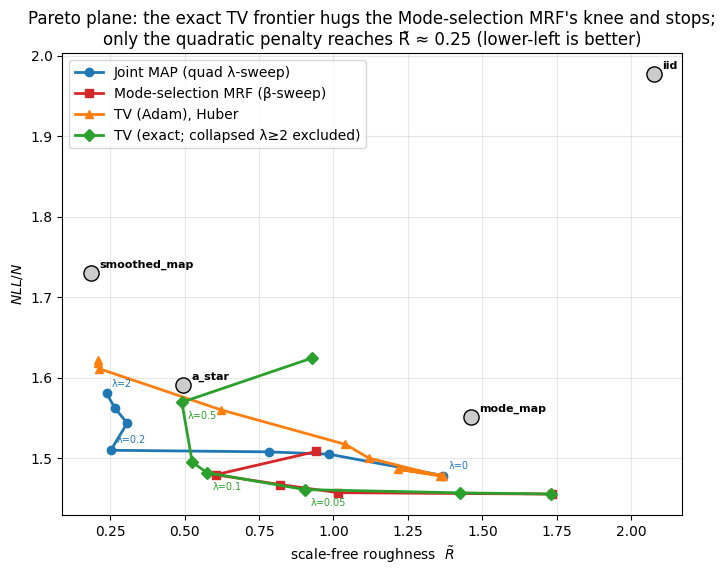

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

# Joint MAP (quadratic λ-sweep).
ax.plot(B["r_tilde"], B["nll_over_n"], "o-", color="C0", lw=2, label="Joint MAP (quad λ-sweep)")
for lam, r, n in zip(B["lambdas"], B["r_tilde"], B["nll_over_n"]):
    if lam in (0.0, 0.2, 2.0):
        ax.annotate(f"λ={lam:g}", (r, n), fontsize=7, color="C0",
                    xytext=(4, 5), textcoords="offset points")

# Mode-selection MRF (discrete β-sweep).
ax.plot(C["r_tilde"], C["nll_over_n"], "s-", color="C3", lw=2, label="Mode-selection MRF (β-sweep)")

# TV (Adam) — Huber penalty swap.
ax.plot(T["adam_tv_r_tilde"], T["adam_tv_nll_over_n"], "^-", color="C1", lw=2,
        label="TV (Adam), Huber")

# TV (exact); variance-collapsed points (λ ≥ 1) excluded — R̃ undefined.
collapsed = np.array([r["variance_collapsed"] == "True" for r in rows_cut])
ax.plot(T["cut_tv_r_tilde"][~collapsed], T["cut_tv_nll_over_n"][~collapsed], "D-",
        color="C2", lw=2, label="TV (exact; collapsed λ≥2 excluded)")
for keep, lam, r, n in zip(~collapsed, T["cut_tv_lambdas"], T["cut_tv_r_tilde"],
                           T["cut_tv_nll_over_n"]):
    if keep and lam in (0.05, 0.1, 0.5):
        ax.annotate(f"λ={lam:g}", (r, n), fontsize=7, color="C2",
                    xytext=(4, -12), textcoords="offset points")

# Baseline anchors.
for name in ANCHORS:
    s = scores_a[name]
    ax.scatter(s["r_tilde"], s["nll_over_n"], s=120, edgecolor="k", color="0.8", zorder=3)
    ax.annotate(name, (s["r_tilde"], s["nll_over_n"]), fontsize=8, fontweight="bold",
                xytext=(6, 4), textcoords="offset points")

ax.set_xlabel(r"scale-free roughness  $\tilde{R}$")
ax.set_ylabel(r"$NLL/N$")
ax.set_title("Pareto plane: the exact TV frontier hugs the Mode-selection MRF's knee and stops;\n"
             "only the quadratic penalty reaches R̃ ≈ 0.25 (lower-left is better)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 5. The non-smearing diagnostic

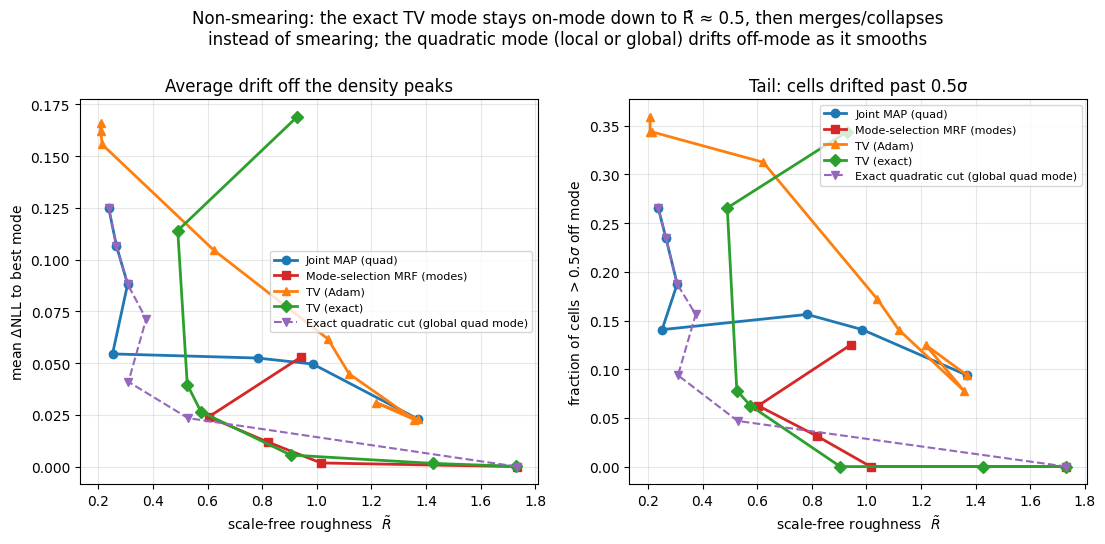

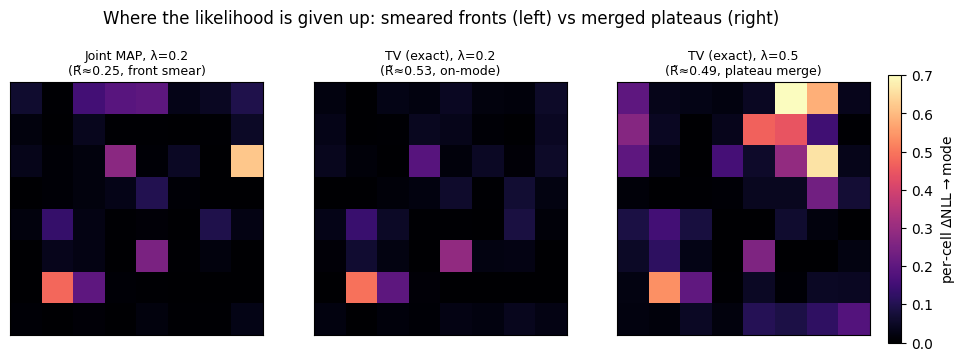

In [6]:
def smear_mean_frac(field):
    """(mean ΔNLL→mode, fraction of cells >0.5σ off mode) vs the Mode-selection MRF's shared modes."""
    delta = rm4.delta_nll_to_best_mode(field, pi, mu, sigma, MODE_VALUES, VALID_MASK)
    return delta["mean"], delta["frac_over"][0]

# Cheap live diagnostic on the loaded fields (no sweep rerun).
b_mean, b_frac = zip(*(smear_mean_frac(f) for f in B["fields"]))
c_mean, c_frac = zip(*(smear_mean_frac(f) for f in C["fields"]))
collapsed = np.array([r["variance_collapsed"] == "True" for r in rows_cut])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
panels = [
    (axes[0], "dnll_to_mode_mean", b_mean, c_mean,
     r"mean $\Delta$NLL to best mode", "Average drift off the density peaks"),
    (axes[1], "dnll_frac_gt_0p125_v1", b_frac, c_frac,
     r"fraction of cells $>0.5\sigma$ off mode", "Tail: cells drifted past 0.5σ"),
]
for ax, key, b_y, c_y, ylab, title in panels:
    ax.plot(B["r_tilde"], b_y, "o-", color="C0", lw=2, label="Joint MAP (quad)")
    ax.plot(C["r_tilde"], c_y, "s-", color="C3", lw=2, label="Mode-selection MRF (modes)")
    ax.plot(T["adam_tv_r_tilde"], [r[key] for r in rows_adam], "^-", color="C1",
            lw=2, label="TV (Adam)")
    ax.plot(T["cut_tv_r_tilde"][~collapsed],
            [r[key] for r, c in zip(rows_cut, collapsed) if not c], "D-", color="C2",
            lw=2, label="TV (exact)")
    ax.plot([r["r_tilde"] for r in rows_quad], [r[key] for r in rows_quad], "v--",
            color="C4", lw=1.5, label="Exact quadratic cut (global quad mode)")
    ax.set_xlabel(r"scale-free roughness  $\tilde{R}$")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Non-smearing: the exact TV mode stays on-mode down to R̃ ≈ 0.5, then merges/collapses\n"
             "instead of smearing; the quadratic mode (local or global) drifts off-mode as it smooths", y=1.06)
plt.show()

# Per-cell ΔNLL maps: Joint MAP's smeared R̃≈0.25 field vs the smoothest
# mode-faithful TV (exact) fields (TV has no R̃≈0.25 point — it collapses first).
map_specs = [
    ("Joint MAP, λ=0.2\n(R̃≈0.25, front smear)", B["fields"][3]),
    ("TV (exact), λ=0.2\n(R̃≈0.53, on-mode)", T["cut_tv_fields"][4]),
    ("TV (exact), λ=0.5\n(R̃≈0.49, plateau merge)", T["cut_tv_fields"][5]),
]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
for ax, (title, fld) in zip(axes, map_specs):
    per_cell = rm4.delta_nll_to_best_mode(fld, pi, mu, sigma, MODE_VALUES, VALID_MASK)["per_cell"]
    im = ax.imshow(per_cell, origin="lower", cmap="magma", vmin=0.0, vmax=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label=r"per-cell $\Delta$NLL$\to$mode")
fig.suptitle("Where the likelihood is given up: smeared fronts (left) vs merged plateaus (right)", y=1.02)
plt.show()

## Appendix

In [7]:
from sampler_research import exact_map
from sampler_research import regularised_map as rm

# 1) Huber gradient vs central finite differences (kink-free point).
lam, delta_h = 0.5, 0.05
x = A["mode_map"] + np.random.default_rng(3).normal(scale=0.5, size=mu.shape[:2])
analytic = rm.objective_gradient(x, pi, mu, sigma, lam, penalty="huber", delta=delta_h, edges=EDGES)
eps, numeric = 1e-6, np.zeros_like(x)
flat = x.reshape(-1)
for i in range(flat.size):
    xp, xm = flat.copy(), flat.copy(); xp[i] += eps; xm[i] -= eps
    jp = rm.objective(xp.reshape(x.shape), pi, mu, sigma, lam, penalty="huber", delta=delta_h, edges=EDGES)
    jm = rm.objective(xm.reshape(x.shape), pi, mu, sigma, lam, penalty="huber", delta=delta_h, edges=EDGES)
    numeric.reshape(-1)[i] = (jp - jm) / (2 * eps)
print(f"Huber grad: max |analytic - FD| = {np.abs(analytic - numeric).max():.2e}")

# 2) Exactness on a tiny instance: cut vs brute-force enumeration (G=5, 2x3, K=2).
rng = np.random.default_rng(0)
mu_s = rng.normal(0.0, 1.0, size=(2, 3, 2))
sigma_s = rng.uniform(0.5, 1.5, size=(2, 3, 2))
raw = rng.uniform(0.2, 1.0, size=(2, 3, 2)); pi_s = raw / raw.sum(-1, keepdims=True)
values, _ = exact_map.value_grid(mu_s, sigma_s, n_levels=5)
U = exact_map.unary_table(values, pi_s, mu_s, sigma_s)
edges_s = grid_edges_8(2, 3)
labelings = np.stack(np.meshgrid(*([np.arange(5)] * 6), indexing="ij"), -1).reshape(-1, 6)
unary_term = U[np.arange(6)[None, :], labelings].sum(1) / 6
tv_term = np.abs(values[labelings[:, edges_s[:, 0]]] - values[labelings[:, edges_s[:, 1]]]).sum(1) / len(edges_s)
enum_min = float(np.min(unary_term + 0.3 * tv_term))
res = exact_map.exact_map_solve(pi_s, mu_s, sigma_s, 0.3, penalty="tv", n_levels=5)
print(f"brute force (5^6 labelings): enum min = {enum_min:.10f}   cut = {res.energy:.10f}   "
      f"agree: {abs(res.energy - enum_min) <= res.quantisation_bound + 1e-9}")

# 3) Solver-integrity numbers from the persisted run.
print(f"quantisation: max gap = {T['cut_tv_quantisation_gap'].max():.2e} "
      f"(bound {T['cut_tv_quantisation_bound'].max():.2e});  quad max gap = "
      f"{T['cut_quad_quantisation_gap'].max():.2e} (bound {T['cut_quad_quantisation_bound'].max():.2e})")
print(f"G-control:   max|Δfield| = {T['cut_tv_gcontrol_max_dfield'].max():.4f} "
      f"≈ h/2 = {float(T['value_grid_tv'][1] - T['value_grid_tv'][0]) / 2:.4f};  "
      f"|ΔJ_TV| ≤ {np.abs(T['cut_tv_gcontrol_delta_j_tv']).max():.1e}")
print(f"tie probe:   max|Δfield| = {T['cut_tv_tie_max_dfield'].max():.1e} (no degenerate optima)")

Huber grad: max |analytic - FD| = 2.96e-10
brute force (5^6 labelings): enum min = 1.2560538837   cut = 1.2560538837   agree: True
quantisation: max gap = 3.06e-06 (bound 3.15e-05);  quad max gap = 4.95e-06 (bound 3.12e-05)
G-control:   max|Δfield| = 0.0310 ≈ h/2 = 0.0310;  |ΔJ_TV| ≤ 1.1e-04
tie probe:   max|Δfield| = 0.0e+00 (no degenerate optima)
